In [ ]:
# Install CasADi in Google Colab
!pip -q install casadi

# Direct Shooting: Inverted Pendulum Swing-Up

Consider an inverted pendulum actuated by a torque $u$ at its pivot. The pendulum dynamics are

$$
I\ddot{\theta} = mgl\sin(\theta) + u,
$$

where $\theta=0$ corresponds to the downward equilibrium and $\theta=\pi$ to the upright equilibrium.

The goal is to find a control trajectory $u(t)$ that moves the pendulum from the downward equilibrium

$$
x(0) =
\begin{bmatrix}
0\\
0
\end{bmatrix}
$$

to the upright equilibrium

$$
x(T) =
\begin{bmatrix}
\pi\\
0
\end{bmatrix}.
$$

We use **direct shooting**: the optimization variables are the discretized control inputs

$$
u_0,\ldots,u_{N-1}.
$$

For a given control sequence, the nonlinear dynamics are integrated forward in time. We minimize the control effort

$$
\min_{u_0,\ldots,u_{N-1}}
\sum_{k=0}^{N-1} u_k^2\Delta t
$$

subject to the final-state constraint

$$
x_N = x(T) =
\begin{bmatrix}
\pi\\
0
\end{bmatrix}.
$$

There are **no torque limits or state constraints**. The swing-up trajectory is obtained entirely from the nonlinear dynamics and the final-state requirement.

Solving trajectory optimization...
Optimization finished.
Optimal cost: 36.69065282769717

Initial state:
[0. 0.]

Desired final state:
[3.14159265 0.        ]

Actual final state:
[ 3.14159265e+00 -1.81799020e-15]

Final-state error:
[ 2.22044605e-15 -1.81799020e-15]


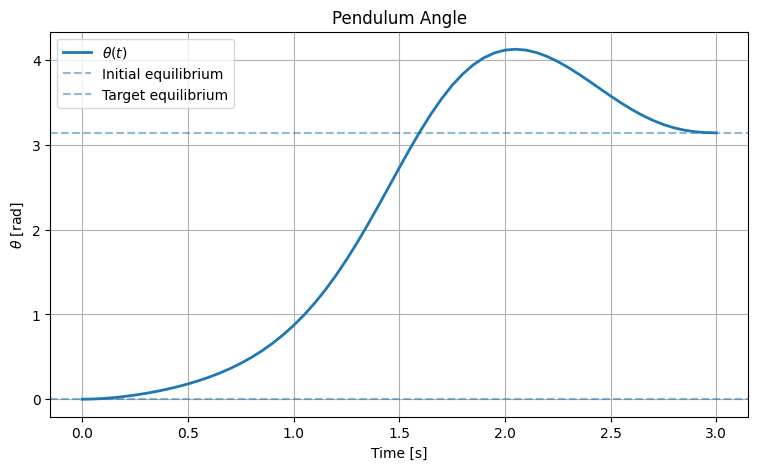

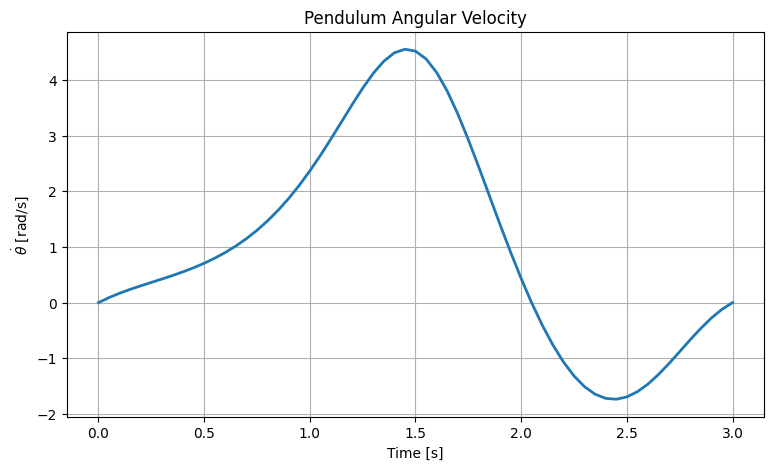

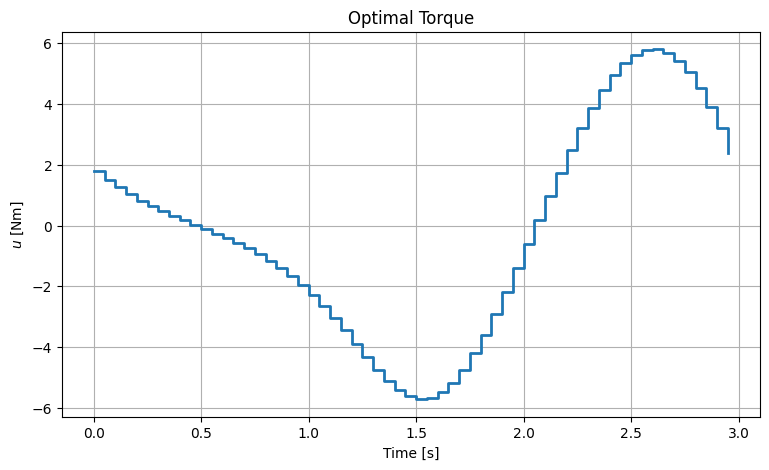

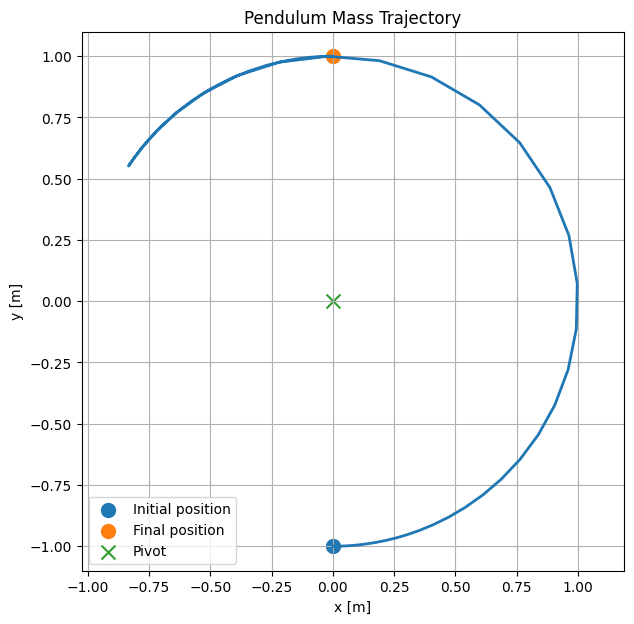

In [3]:
# ============================================================
# Inverted Pendulum Trajectory Optimization
# Direct Shooting with CasADi
#
# Task:
#   Move the pendulum from the downward equilibrium
#   to the upright equilibrium.
#
# No torque constraints.
# No state constraints.
#
# Optimization variable:
#   sequence of torques u_0, ..., u_{N-1}
#
# Objective:
#   minimize integral of u(t)^2
#
# Constraint:
#   x(T) = x_final
# ============================================================


import casadi as ca
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. Pendulum parameters
# ============================================================

m = 1.0       # mass [kg]
l = 1.0       # distance from pivot to center of mass [m]
I = m*l**2    # moment of inertia [kg m^2]
g = 9.81      # gravity [m/s^2]


# ============================================================
# 2. Pendulum dynamics
#
# State:
#
#       x = [theta, theta_dot]
#
# theta = 0       -> downward equilibrium
# theta = pi      -> upright equilibrium
#
# Dynamics:
#
#       I theta_ddot = m g l sin(theta) + u
#
# where u is the applied torque.
# ============================================================

x = ca.MX.sym("x", 2)
u = ca.MX.sym("u")

theta = x[0]
theta_dot = x[1]

theta_ddot = (
    m*g*l*ca.sin(theta) + u
) / I

xdot = ca.vertcat(
    theta_dot,
    theta_ddot
)

dynamics = ca.Function(
    "dynamics",
    [x, u],
    [xdot]
)


# ============================================================
# 3. RK4 integration step
# ============================================================

def rk4(x, u, dt):

    k1 = dynamics(x, u)

    k2 = dynamics(
        x + dt/2 * k1,
        u
    )

    k3 = dynamics(
        x + dt/2 * k2,
        u
    )

    k4 = dynamics(
        x + dt * k3,
        u
    )

    return x + dt/6 * (
        k1 + 2*k2 + 2*k3 + k4
    )


# ============================================================
# 4. Trajectory specification
# ============================================================

T = 3.0       # trajectory duration [s]
N = 60        # number of shooting intervals
dt = T / N


# Initial state:
# pendulum hanging down, zero velocity
x0 = np.array([
    0.0,
    0.0
])


# Final state:
# pendulum upright, zero velocity
xf = np.array([
    np.pi,
    0.0
])


# ============================================================
# 5. Direct shooting formulation
#
# Decision variables:
#
#       U = [u_0, u_1, ..., u_{N-1}]
#
# Given U, integrate the dynamics from x0 to obtain x(T).
# ============================================================

U = ca.MX.sym("U", N)

X = ca.DM(x0)

cost = 0

for k in range(N):

    uk = U[k]

    # Propagate the dynamics
    X = rk4(X, uk, dt)

    # Control-effort cost
    cost += uk**2 * dt


# Final-state constraint
final_constraint = X - xf


# ============================================================
# 6. Nonlinear program
# ============================================================

nlp = {
    "x": U,
    "f": cost,
    "g": final_constraint
}

opts = {
    "ipopt.print_level": 0,
    "print_time": False,
    "ipopt.max_iter": 2000
}

solver = ca.nlpsol(
    "solver",
    "ipopt",
    nlp,
    opts
)


# ============================================================
# 7. Initial guess
# ============================================================

# Small initial perturbation in the torque.
#
# A completely zero initial guess is also possible,
# but a small nonzero guess can help the optimizer
# escape the equilibrium trajectory.

t_guess = np.linspace(0, T, N)

U0 = (
    2.0
    * np.sin(2*np.pi*t_guess/T)
)


# ============================================================
# 8. Solve
# ============================================================

print("Solving trajectory optimization...")

solution = solver(
    x0=U0,
    lbg=np.zeros(2),
    ubg=np.zeros(2)
)

print("Optimization finished.")


# Optimal control
U_opt = np.array(
    solution["x"]
).flatten()

print("Optimal cost:",
      float(solution["f"]))


# ============================================================
# 9. Simulate the optimal trajectory
# ============================================================

X_sim = np.zeros((2, N+1))

X_sim[:, 0] = x0

for k in range(N):

    X_sim[:, k+1] = np.array(
        rk4(
            ca.DM(X_sim[:, k]),
            ca.DM(U_opt[k]),
            dt
        )
    ).flatten()


t = np.linspace(0, T, N+1)


# ============================================================
# 10. Check final state
# ============================================================

print("\nInitial state:")
print(X_sim[:, 0])

print("\nDesired final state:")
print(xf)

print("\nActual final state:")
print(X_sim[:, -1])

print("\nFinal-state error:")
print(X_sim[:, -1] - xf)


# ============================================================
# 11. Plot pendulum angle
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    t,
    X_sim[0, :],
    linewidth=2,
    label=r"$\theta(t)$"
)

plt.axhline(
    0,
    linestyle="--",
    alpha=0.5,
    label="Initial equilibrium"
)

plt.axhline(
    np.pi,
    linestyle="--",
    alpha=0.5,
    label="Target equilibrium"
)

plt.xlabel("Time [s]")
plt.ylabel(r"$\theta$ [rad]")
plt.title("Pendulum Angle")
plt.grid(True)
plt.legend()

plt.show()


# ============================================================
# 12. Plot angular velocity
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    t,
    X_sim[1, :],
    linewidth=2
)

plt.xlabel("Time [s]")
plt.ylabel(r"$\dot{\theta}$ [rad/s]")
plt.title("Pendulum Angular Velocity")
plt.grid(True)

plt.show()


# ============================================================
# 13. Plot torque
# ============================================================

plt.figure(figsize=(9, 5))

plt.step(
    t[:-1],
    U_opt,
    where="post",
    linewidth=2
)

plt.xlabel("Time [s]")
plt.ylabel(r"$u$ [Nm]")
plt.title("Optimal Torque")
plt.grid(True)

plt.show()


# ============================================================
# 14. Plot pendulum trajectory in the plane
# ============================================================

# Position of the pendulum mass
px = l * np.sin(X_sim[0, :])
py = -l * np.cos(X_sim[0, :])


plt.figure(figsize=(7, 7))

plt.plot(
    px,
    py,
    linewidth=2
)

plt.scatter(
    px[0],
    py[0],
    s=100,
    label="Initial position"
)

plt.scatter(
    px[-1],
    py[-1],
    s=100,
    label="Final position"
)

# Pivot
plt.scatter(
    0,
    0,
    s=100,
    marker="x",
    label="Pivot"
)

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Pendulum Mass Trajectory")
plt.axis("equal")
plt.grid(True)
plt.legend()

plt.show()

# Direct Shooting: Two-Link Robot Arm

Consider a planar two-link robot arm with two revolute joints. The robot dynamics are

$$
M(q)\ddot{q} + C(q,\dot{q})\dot{q} + G(q) = \tau,
$$

where

$$
q =
\begin{bmatrix}
q_1\\
q_2
\end{bmatrix}
$$

is the vector of joint angles and $\tau$ is the vector of joint torques.

The goal is to find a control trajectory $\tau(t)$ that moves the robot from an initial configuration $A$ to a final configuration $B$:

$$
x(0) =
\begin{bmatrix}
q_A\\
0
\end{bmatrix},
\qquad
x(T) =
\begin{bmatrix}
q_B\\
0
\end{bmatrix}.
$$

We use **direct shooting**: the optimization variables are the discretized control inputs

$$
\tau_0,\ldots,\tau_{N-1}.
$$

For a given torque sequence, the nonlinear robot dynamics are integrated forward in time. We minimize the control effort

$$
\min_{\tau_0,\ldots,\tau_{N-1}}
\sum_{k=0}^{N-1} \|\tau_k\|^2\Delta t
$$

subject to the final-state constraint

$$
x_N = x(T) =
\begin{bmatrix}
q_B\\
0
\end{bmatrix}.
$$

There are **no torque limits or state constraints**. The resulting motion is determined by the robot dynamics, the final-state requirement, and the control-effort cost.

Solving trajectory optimization...


CasADi - 2026-09-29 12:10:00 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-09-29 12:10:01 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-09-29 12:10:01 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-09-29 12:10:01 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-09-29 12:10:01 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-09-29 12:10:01 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-09-29 12:10:07 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 0, col 0).")

Optimization finished.
Optimal cost: 171.45888653033134

Initial state:
[-1.57079633  0.          0.          0.        ]

Desired final state:
[0.78539816 1.57079633 0.         0.        ]

Actual final state:
[ 0.77338405 -5.42262253 -0.00555934  0.01619932]

Final-state error:
[-1.20141152e-02 -6.99341886e+00 -5.55933512e-03  1.61993160e-02]


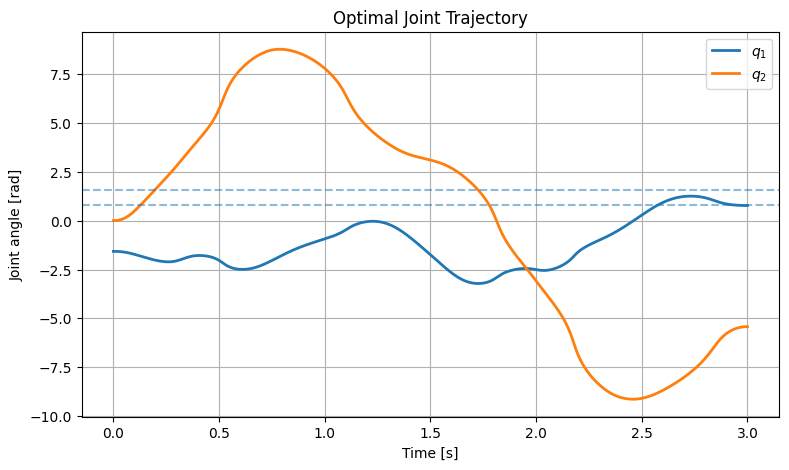

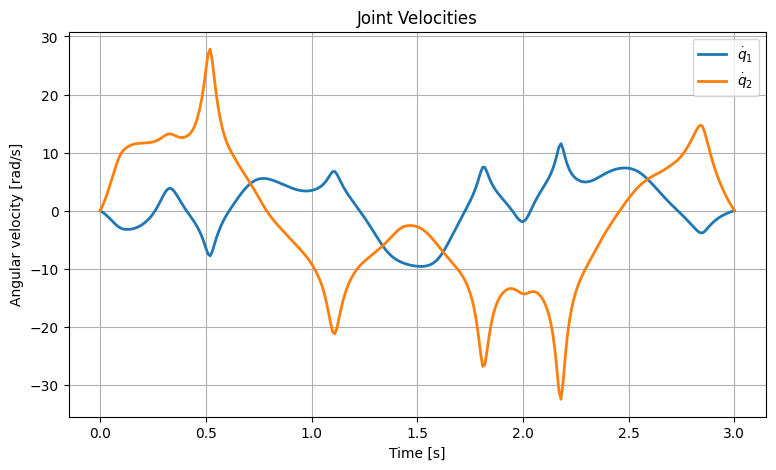

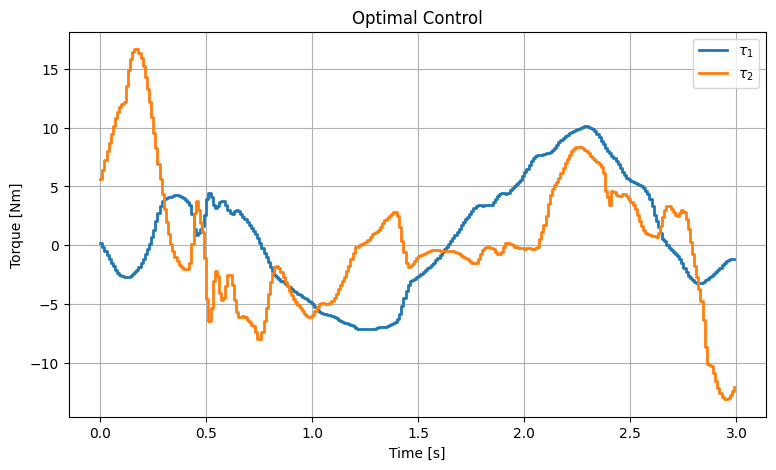

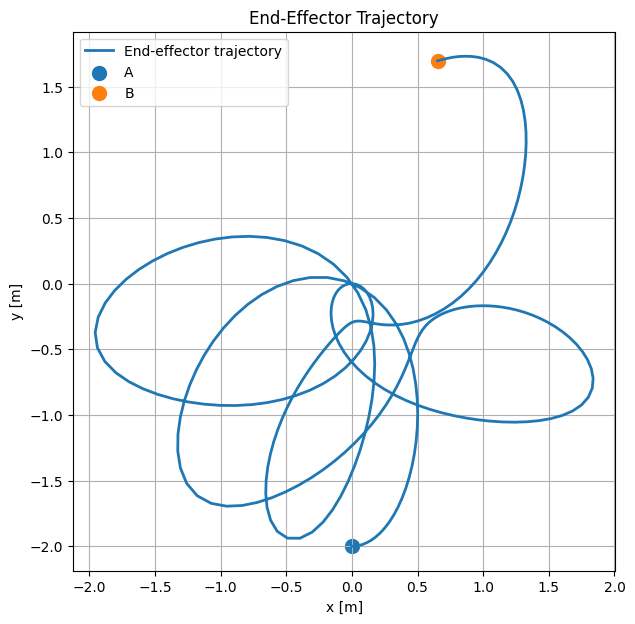

In [2]:
# ============================================================
# Two-Link Robot Trajectory Optimization
# Direct Shooting with CasADi
# ============================


import casadi as ca
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. Robot parameters
# ============================================================

m1 = 1.0       # link 1 mass
m2 = 1.0       # link 2 mass

l1 = 1.0       # link 1 length
l2 = 1.0       # link 2 length

lc1 = l1 / 2   # center of mass of link 1
lc2 = l2 / 2   # center of mass of link 2

I1 = m1 * l1**2 / 12
I2 = m2 * l2**2 / 12

g = 9.81


# ============================================================
# 2. Robot dynamics
#
# State:
#     x = [q1, q2, q1_dot, q2_dot]
#
# Dynamics:
#
#     M(q) q_ddot + C(q,q_dot) q_dot + G(q) = tau
#
# ============================================================

x = ca.MX.sym("x", 4)
u = ca.MX.sym("u", 2)

q1 = x[0]
q2 = x[1]
dq1 = x[2]
dq2 = x[3]

q = ca.vertcat(q1, q2)
dq = ca.vertcat(dq1, dq2)

tau = u


# Mass matrix
M11 = (
    I1 + I2
    + m1 * lc1**2
    + m2 * (l1**2 + lc2**2 + 2*l1*lc2*ca.cos(q2))
)

M12 = I2 + m2 * (lc2**2 + l1*lc2*ca.cos(q2))

M22 = I2 + m2 * lc2**2

M = ca.vertcat(
    ca.horzcat(M11, M12),
    ca.horzcat(M12, M22)
)


# Coriolis / centrifugal matrix
h = m2 * l1 * lc2 * ca.sin(q2)

C = ca.vertcat(
    ca.horzcat(-h*dq2, -h*(dq1 + dq2)),
    ca.horzcat( h*dq1, 0)
)


# Gravity vector
G = ca.vertcat(
    (m1*lc1 + m2*l1)*g*ca.cos(q1)
    + m2*lc2*g*ca.cos(q1 + q2),

    m2*lc2*g*ca.cos(q1 + q2)
)


# Solve for accelerations
ddq = ca.solve(
    M,
    tau - C @ dq - G
)


# Continuous-time dynamics
xdot = ca.vertcat(
    dq,
    ddq
)

dynamics = ca.Function(
    "dynamics",
    [x, u],
    [xdot]
)


# ============================================================
# 3. RK4 integrator
# ============================================================

def rk4(x, u, dt):

    k1 = dynamics(x, u)

    k2 = dynamics(
        x + dt/2 * k1,
        u
    )

    k3 = dynamics(
        x + dt/2 * k2,
        u
    )

    k4 = dynamics(
        x + dt * k3,
        u
    )

    return x + dt/6 * (
        k1 + 2*k2 + 2*k3 + k4
    )


# ============================================================
# 4. Trajectory-planning problem
# ============================================================

T = 3.0          # total trajectory duration
N = 300           # number of shooting intervals
dt = T / N


# Initial and final configurations
q0 = np.array([
    -np.pi/2,
     0.0
])

qf = np.array([
     np.pi/4,
     np.pi/2
])


# Start and final velocities
dq0 = np.zeros(2)
dqf = np.zeros(2)

x0 = np.concatenate([q0, dq0])
xf = np.concatenate([qf, dqf])


# ============================================================
# 5. Direct shooting
#
# Decision variables:
#
#     U = [u_0, u_1, ..., u_{N-1}]
#
# For every candidate U we simulate the robot forward.
#
# The optimization therefore looks like
#
#     minimize    sum ||u_k||^2
#
#     subject to  x_N(U) = x_f
#
# ============================================================

U = ca.MX.sym("U", 2, N)


# Initial state
X = ca.MX(x0)

cost = 0

for k in range(N):

    uk = U[:, k]

    # Integrate dynamics
    X = rk4(X, uk, dt)

    # Minimize control effort
    cost += ca.sumsqr(uk) * dt


# Final-state constraint
final_constraint = X - xf


# ============================================================
# 6. Create nonlinear optimization problem
# ============================================================

nlp = {
    "x": ca.vec(U),
    "f": cost,
    "g": final_constraint
}

opts = {
    "ipopt.print_level": 0,
    "print_time": False,
    "ipopt.max_iter": 1000
}

solver = ca.nlpsol(
    "solver",
    "ipopt",
    nlp,
    opts
)


# ============================================================
# 7. Initial guess
# ============================================================

# A simple initial guess: zero torque
U0 = np.zeros((2, N))


# ============================================================
# 8. Solve
# ============================================================

print("Solving trajectory optimization...")

solution = solver(
    x0=U0.reshape(-1, order="F"),
    lbg=np.zeros(4),
    ubg=np.zeros(4)
)

print("Optimization finished.")

print("Optimal cost:",
      float(solution["f"]))


# Extract optimal controls
U_opt = np.array(
    solution["x"]
).reshape((2, N), order="F")


# ============================================================
# 9. Simulate the optimal trajectory
# ============================================================

X_sim = np.zeros((4, N+1))
X_sim[:, 0] = x0

for k in range(N):

    X_sim[:, k+1] = np.array(
        rk4(
            ca.DM(X_sim[:, k]),
            ca.DM(U_opt[:, k]),
            dt
        )
    ).flatten()


t = np.linspace(0, T, N+1)


# ============================================================
# 10. Check final state
# ============================================================

print("\nInitial state:")
print(X_sim[:, 0])

print("\nDesired final state:")
print(xf)

print("\nActual final state:")
print(X_sim[:, -1])

print("\nFinal-state error:")
print(X_sim[:, -1] - xf)


# ============================================================
# 11. Plot joint positions
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    t,
    X_sim[0, :],
    linewidth=2,
    label=r"$q_1$"
)

plt.plot(
    t,
    X_sim[1, :],
    linewidth=2,
    label=r"$q_2$"
)

plt.axhline(
    qf[0],
    linestyle="--",
    alpha=0.5
)

plt.axhline(
    qf[1],
    linestyle="--",
    alpha=0.5
)

plt.xlabel("Time [s]")
plt.ylabel("Joint angle [rad]")
plt.title("Optimal Joint Trajectory")
plt.grid(True)
plt.legend()
plt.show()


# ============================================================
# 12. Plot joint velocities
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    t,
    X_sim[2, :],
    linewidth=2,
    label=r"$\dot q_1$"
)

plt.plot(
    t,
    X_sim[3, :],
    linewidth=2,
    label=r"$\dot q_2$"
)

plt.xlabel("Time [s]")
plt.ylabel("Angular velocity [rad/s]")
plt.title("Joint Velocities")
plt.grid(True)
plt.legend()
plt.show()


# ============================================================
# 13. Plot control torques
# ============================================================

plt.figure(figsize=(9, 5))

plt.step(
    t[:-1],
    U_opt[0, :],
    where="post",
    linewidth=2,
    label=r"$\tau_1$"
)

plt.step(
    t[:-1],
    U_opt[1, :],
    where="post",
    linewidth=2,
    label=r"$\tau_2$"
)

plt.xlabel("Time [s]")
plt.ylabel("Torque [Nm]")
plt.title("Optimal Control")
plt.grid(True)
plt.legend()
plt.show()


# ============================================================
# 14. Calculate Cartesian end-effector trajectory
# ============================================================

q1_sim = X_sim[0, :]
q2_sim = X_sim[1, :]

x_ee = (
    l1 * np.cos(q1_sim)
    + l2 * np.cos(q1_sim + q2_sim)
)

y_ee = (
    l1 * np.sin(q1_sim)
    + l2 * np.sin(q1_sim + q2_sim)
)


# ============================================================
# 15. Plot end-effector path
# ============================================================

plt.figure(figsize=(7, 7))

plt.plot(
    x_ee,
    y_ee,
    linewidth=2,
    label="End-effector trajectory"
)

plt.scatter(
    x_ee[0],
    y_ee[0],
    s=100,
    label="A"
)

plt.scatter(
    x_ee[-1],
    y_ee[-1],
    s=100,
    label="B"
)

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("End-Effector Trajectory")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()